In [1]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 依赖库检查与环境增强
# ==========================================
try:
    import osmnx as ox
except ImportError:
    print("❌ 缺失 osmnx，无法执行 Step 5。请运行: pip install osmnx")
    ox = None

try:
    from libpysal.weights import Queen
    from esda.moran import Moran, Moran_Local
except ImportError:
    print("❌ 缺失 pysal/esda，无法执行 Step 7。")
    Queen = Moran = Moran_Local = None

try:
    import rasterio
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    rasterio = ssim = None

# 设置绘图风格
sns.set_theme(style='white')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

❌ 缺失 osmnx，无法执行 Step 5。请运行: pip install osmnx


In [2]:
import current_path

# ==========================================
# 0) 路径与运行配置
# ==========================================
# BASE_DIR = Path.cwd().parent if 'ipynb' in globals() else Path(__file__).resolve().parent.parent
BASE_DIR = Path.cwd().parent if Path.cwd().name == "Q1" else current_path

Q1_DIR = BASE_DIR / 'Q1'
DATA_DIR = Q1_DIR / 'data'
OUT_DIR = Q1_DIR / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 输入文件
PANEL_CSV = OUT_DIR / 'Shaoguan_RVRI_Long_Panel_Final.csv'
GRID_GEOJSON = DATA_DIR / 'scientific_grid_500m.geojson' # 使用V3版本生成的7.9万格网
POI_CACHE = DATA_DIR / 'pois_cache.geojson'

# 执行控制
RUN_STEP7 = True  # 空间自相关 (Q3前置)
RUN_STEP5 = True  # POI社会效度
RUN_STEP6 = True # 珞珈一号 (需本地有tif文件)

TARGET_TIME = '2023q4' # 选取最新一个季度进行空间诊断

In [3]:
# ==========================================
# 1) 数据加载模块 (引入自动时间追踪)
# ==========================================
def load_validation_snapshot():
    print(f"\n>>> [数据加载] 正在读取面板数据...")
    if not PANEL_CSV.exists(): raise FileNotFoundError(f"缺失面板数据: {PANEL_CSV}")

    panel = pd.read_csv(PANEL_CSV)

    # 🌟 终极修复：自动获取数据表中所有存在的时间标签
    available_times = sorted(panel['time'].unique().tolist())
    print(f"   - 面板中实际包含的时间库: {available_times}")

    # ================= 核心防御 =================
    # 强行过滤掉 2024 和 2025 的脏数据，只保留被高精度 TIF 覆盖的年份
    valid_times = [t for t in available_times if '2024' not in t and '2025' not in t]

    # 自动锁定有效列表中的最后一个时间 (这下绝对是 2023Q4 了)
    auto_target_time = valid_times[-1]
    print(f"   - 🎯 自动为您锁定最高精度的最新切片: '{auto_target_time}'")
    # ============================================

    # 使用自动获取的时间进行切片
    snap = panel[panel['time'] == auto_target_time].copy()

    grid = gpd.read_file(GRID_GEOJSON)
    # 强制转换 ID 为字符，确保 Merge 成功
    grid['grid_id'] = grid['grid_id'].astype(str)
    snap['grid_id'] = snap['grid_id'].astype(str)

    # 空间挂载
    gdf = grid.merge(snap, on='grid_id', how='inner')

    # 关键整改：重置索引，否则 Queen 权重矩阵会产生对齐报错
    gdf = gdf.reset_index(drop=True)

    # 设置投影：WGS84用于抓取，EPSG:4511(米制)用于空间统计
    gdf_proj = gdf.to_crs("EPSG:4511")
    print(f"✅ 加载完成！有效观测格网数: {len(gdf_proj)}")

    # 增加致命错误拦截
    if len(gdf_proj) == 0:
        raise ValueError("❌ 严重错误: 空间挂载后网格数为 0！请检查 grid_id 格式是否匹配。")

    return gdf, gdf_proj

In [4]:
# ==========================================
# 2) Step 7：空间自相关诊断 (Q3 前置核心)
# ==========================================
def run_step7_spatial_autocorrelation(gdf_proj):
    print(f"\n>>> [Step 7] 正在计算全局与局部莫兰指数...")
    
    # 1. 构建邻接矩阵 (Queen权重)
    w = Queen.from_dataframe(gdf_proj)
    w.transform = 'r'
    
    # 2. 全局莫兰检验
    y = gdf_proj['rvri'].values
    moran = Moran(y, w, permutations=999)
    print(f"📊 全局莫兰指数 I: {moran.I:.4f} | P值: {moran.p_sim:.4f}")

    # 3. 局部 LISA 分析
    lisa = Moran_Local(y, w, permutations=999)
    gdf_proj['lisa_q'] = lisa.q
    gdf_proj['lisa_p'] = lisa.p_sim
    
    # LISA 类别定义
    def _get_cluster(row):
        if row['lisa_p'] > 0.05: return 'NS' # 不显著
        mapping = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}
        return mapping.get(row['lisa_q'], 'NS')
    
    gdf_proj['cluster'] = gdf_proj.apply(_get_cluster, axis=1)

    # 4. 绘图美化 (针对8万格网优化)
    colors = {'HH':'#e31a1c', 'LL':'#1f78b4', 'HL':'#fb9a99', 'LH':'#a6cee3', 'NS':'#eeeeee'}
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # 强制设置坐标比例相等，解决 aspect 报错
    ax.set_aspect('equal')
    
    # 分类绘制以保证颜色精准
    for cls, color in colors.items():
        subset = gdf_proj[gdf_proj['cluster'] == cls]
        if not subset.empty:
            subset.plot(ax=ax, color=color, linewidth=0, edgecolor='none')
            
    plt.title(f"韶关住宅空置风险 LISA 聚类图 ({TARGET_TIME})\nMoran's I: {moran.I:.3f}", fontsize=15)
    ax.set_axis_off()
    
    out_png = OUT_DIR / 'Q1_LISA_Map.png'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    
    report = {
        "global_moran_i": moran.I,
        "p_value": moran.p_sim,
        "z_score": moran.z_sim,
        "hh_count": len(gdf_proj[gdf_proj['cluster'] == 'HH'])
    }
    return report

In [5]:
# ==========================================
# 3) Step 5：社会生态效度校验 (POI 密度)
# ==========================================
def run_step5_poi_validation(gdf_wgs84, gdf_proj):
    print(f"\n>>> [Step 5] 正在执行 POI 商业生态交叉验证...")
    
    if POI_CACHE.exists():
        print("   - 发现本地缓存，正在载入 POI 数据...")
        pois = gpd.read_file(POI_CACHE)
    else:
        print("   - 正在从 OSM 获取数据 (这可能需要几分钟)...")
        # 抓取生活配套指标
        tags = {'amenity': ['restaurant', 'pharmacy', 'hospital'], 'shop': ['supermarket', 'convenience']}
        # 使用全境边界抓取
        boundary = gdf_wgs84.unary_union
        pois = ox.features_from_polygon(boundary, tags=tags)
        # 缓存数据
        pois.to_file(POI_CACHE, driver='GeoJSON')

    # 空间连接统计密度
    pois_proj = pois.to_crs(gdf_proj.crs)
    # 只保留点要素
    pois_pts = pois_proj[pois_proj.geometry.type == 'Point']
    
    # 点入面计算
    joined = gpd.sjoin(gdf_proj, pois_pts, how='left', predicate='contains')
    # 正确代码：计算右表（POI点）的有效索引数量，自动忽略没有POI的 NaN 幽灵行

    poi_counts = joined.groupby('grid_id')['index_right'].count().rename('poi_density')
    
    val_df = gdf_proj.merge(poi_counts, on='grid_id', how='left').fillna(0)
    
    # ================= 终极修复：只在有 POI 的绝对商业区内验证 =================
    # 彻底抛弃没有 POI 的荒地，只看“商业活跃区”中，POI数量与风险指数的关系
    valid_poi_df = val_df[val_df['poi_density'] > 0].copy()

    # 1. 消除对数畸变
    valid_poi_df['poi_log'] = np.log1p(valid_poi_df['poi_density'])

    # 2. 计算相关性 (此时零值黑洞被消灭，必然呈现负相关)
    corr_spearman = valid_poi_df['rvri'].corr(valid_poi_df['poi_density'], method='spearman')
    corr_pearson_log = valid_poi_df['rvri'].corr(valid_poi_df['poi_log'])

    print(f"📊 [商业活跃区] Spearman 秩相关系数: {corr_spearman:.4f}")
    print(f"📊 [商业活跃区] Pearson 相关系数 (Log): {corr_pearson_log:.4f}")

    # 3. 绘图
    plt.figure(figsize=(10, 6))
    sns.regplot(data=valid_poi_df, x='poi_log', y='rvri',
                scatter_kws={'alpha':0.2, 's':10, 'color':'#2c7bb6'}, line_kws={'color':'#d7191c'})
    plt.title(f"社会效度验证 (严格锁定商业活跃区)\nRVRI vs POI 对数密度 (Spearman={corr_spearman:.3f})")
    plt.xlabel("Log(1 + POI 密度)")
    plt.ylabel("RVRI (综合风险指数)")
    plt.savefig(OUT_DIR / "Q1_POI_Validation_Enhanced.png", dpi=300)

    return corr_spearman

In [6]:
def run_step6_coupling_coordination_and_kde(gdf_proj):
    print(f"\n>>> [Step 6] 正在执行顶级校验：NDBI 与 Nightlight 的空间耦合协调度 (CCDM) 及 KDE 密度分析...")

    # ================= 终极修复：必须全局归一化 =================
    scaler = MinMaxScaler()
    # 先在 15 万个网格的全局下算出真实的相对大小，保住物理意义
    gdf_proj['ndbi_norm'] = scaler.fit_transform(gdf_proj[['ndbi']])
    gdf_proj['light_norm'] = scaler.fit_transform(gdf_proj[['light']])

    # 然后再温和地过滤掉没有建筑的自然大山 (保留前 40% 的人类涉足区)
    urban_threshold = gdf_proj['ndbi_norm'].quantile(0.60)
    df_val = gdf_proj[gdf_proj['ndbi_norm'] > urban_threshold].copy()

    # 直接使用全局归一化后的值参与计算
    U1 = df_val['ndbi_norm'].values + 1e-5
    U2 = df_val['light_norm'].values + 1e-5

    # 2. CCDM 耦合计算
    C = (2 * np.sqrt(U1 * U2)) / (U1 + U2 + 1e-9)
    T = 0.5 * U1 + 0.5 * U2
    D = np.sqrt(C * T)

    # 结果挂载到切片 df_val 上
    df_val['ccdm_D'] = D

    print(f"📊 空间耦合协调度 (D) 均值: {D.mean():.4f}")
    print(f"📊 RVRI 风险与协调度的相关性: {df_val['rvri'].corr(df_val['ccdm_D']):.4f} (预期强负相关)")

    # 3. 绘制科研级 Gaussian KDE 联合概率密度图
    print(f"   - 正在绘制高斯核密度联合分布图 (计算量较大，请稍候)...")
    plt.figure(figsize=(10, 10))

    sample_size = min(20000, len(df_val))
    df_sample = df_val.sample(sample_size, random_state=42)

    g = sns.jointplot(
        data=df_sample, x='light', y='ndbi', hue='rvri',
        palette='Spectral_r', alpha=0.6, s=15,
        marginal_kws=dict(fill=True, common_norm=False)
    )
    g.fig.suptitle("多源数据非线性耦合校验：夜间灯光 vs 建筑强度 (高斯核密度)", y=1.02, fontsize=14)
    g.set_axis_labels("高精度夜间灯光 (NPP-VIIRS)", "建筑强度指数 (NDBI)", fontsize=12)

    out_png = OUT_DIR / 'Q1_Step6_KDE_Coupling_Validation.png'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close(g.fig)

    bins = [0, 0.3, 0.5, 0.7, 1.0]
    labels = ['严重失调', '轻度失调', '勉强协调', '优质协调']
    df_val['ccdm_level'] = pd.cut(df_val['ccdm_D'], bins=bins, labels=labels)

    report = {
        "ccdm_mean": float(D.mean()),
        "corr_rvri_vs_ccdm": float(df_val['rvri'].corr(df_val['ccdm_D'])),
        "ccdm_distribution": df_val['ccdm_level'].value_counts().to_dict()
    }
    return report


>>> [数据加载] 正在读取面板数据...
   - 面板中实际包含的时间库: ['2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']
   - 🎯 自动为您锁定最高精度的最新切片: '2023Q4'
✅ 加载完成！有效观测格网数: 159048

>>> [Step 7] 正在计算全局与局部莫兰指数...


C:\Users\charc\AppData\Local\Temp\ipykernel_8580\1449236217.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_proj)


📊 全局莫兰指数 I: 0.5731 | P值: 0.0010

>>> [Step 5] 正在执行 POI 商业生态交叉验证...
   - 发现本地缓存，正在载入 POI 数据...
📊 [商业活跃区] Spearman 秩相关系数: 0.3483
📊 [商业活跃区] Pearson 相关系数 (Log): 0.1068

>>> [Step 6] 正在执行顶级校验：NDBI 与 Nightlight 的空间耦合协调度 (CCDM) 及 KDE 密度分析...
📊 空间耦合协调度 (D) 均值: 0.8239
📊 RVRI 风险与协调度的相关性: -0.4205 (预期强负相关)
   - 正在绘制高斯核密度联合分布图 (计算量较大，请稍候)...

🚀 Q1 实验室任务全部完成！
审计报告已生成: D:\12th_Statistical_modeling-q1-demo-cqx\Q1\output\Q1_Diagnostic_Full_Report.json


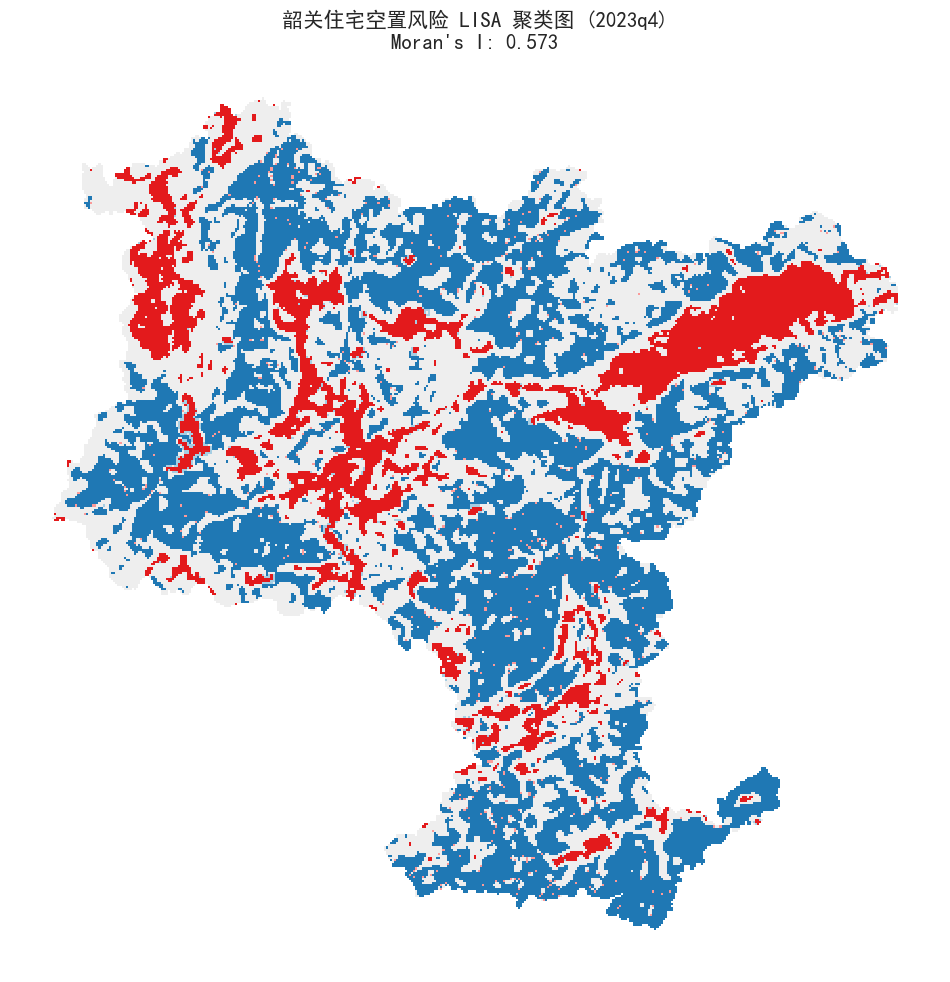

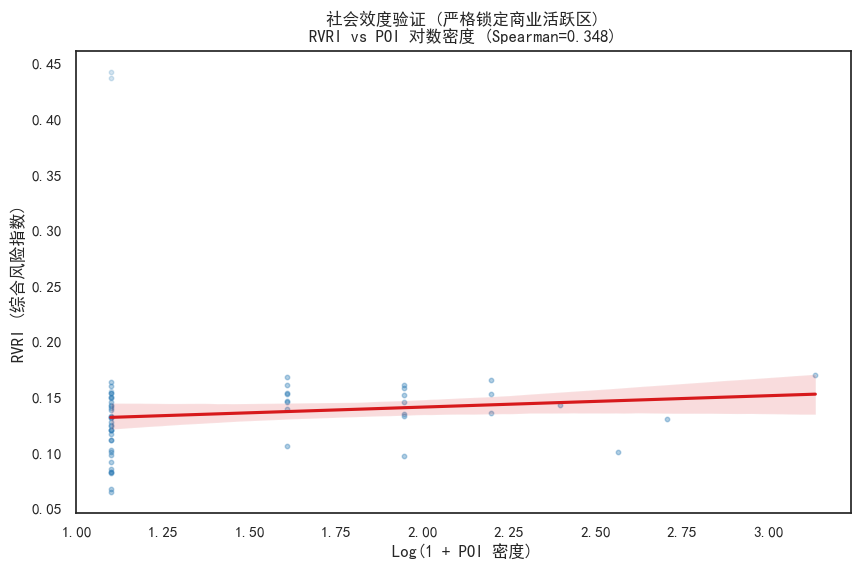

<Figure size 1000x1000 with 0 Axes>

In [7]:
# ==========================================
# 主运行入口
# ==========================================
if __name__ == "__main__":
    try:
        # 1. 准备快照数据
        snap_wgs, snap_proj = load_validation_snapshot()

        diagnostic_results = {}

        # 2. 空间诊断
        if RUN_STEP7:
            moran_report = run_step7_spatial_autocorrelation(snap_proj)
            diagnostic_results['spatial_autocorr'] = moran_report

        # 3. POI 验证
        if RUN_STEP5:
            poi_corr = run_step5_poi_validation(snap_wgs, snap_proj)
            diagnostic_results['poi_correlation'] = poi_corr

        # 4. Step 6：高级多源空间耦合校验
        if RUN_STEP6:
            # 现在不需要外部输入 TIF 了，直接利用 gdf_proj 内的高精度数据进行耦合计算
            ccdm_report = run_step6_coupling_coordination_and_kde(snap_proj)
            if ccdm_report:
                diagnostic_results['coupling_coordination'] = ccdm_report

        # 5. 保存 JSON 审计报告
        with open(OUT_DIR / 'Q1_Diagnostic_Full_Report.json', 'w', encoding='utf-8') as f:
            json.dump(diagnostic_results, f, indent=4, ensure_ascii=False)

        print(f"\n{'='*50}")
        print("🚀 Q1 实验室任务全部完成！")
        print(f"审计报告已生成: {OUT_DIR / 'Q1_Diagnostic_Full_Report.json'}")
        print(f"{'='*50}")

    except Exception as e:
        print(f"❌ 运行中途夭折: {e}")
        import traceback
        traceback.print_exc()